# Imports e Configuração

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
import joblib
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

TECNICA_ATUAL = "UnderSampling" 
PASTA_DADOS = os.path.join("..", "PreProcessing", TECNICA_ATUAL)

NOME_X_TRAIN = "X_train_under.csv"
NOME_Y_TRAIN = "y_train_under.csv"
NOME_X_TEST  = "X_test_scaled.csv"
NOME_Y_TEST  = "y_test.csv"

print(f"📘 Iniciando Treinamento Árvore de Decisão")
print(f"📂 Buscando dados no caminho relativo: {PASTA_DADOS}")

📘 Iniciando Treinamento Árvore de Decisão
📂 Buscando dados no caminho relativo: ..\PreProcessing\UnderSampling


# Carregamento de dados

In [2]:
path_X_train = os.path.join(PASTA_DADOS, NOME_X_TRAIN)
path_y_train = os.path.join(PASTA_DADOS, NOME_Y_TRAIN)
path_X_test  = os.path.join(PASTA_DADOS, NOME_X_TEST)
path_y_test  = os.path.join(PASTA_DADOS, NOME_Y_TEST)

arquivos_necessarios = [path_X_train, path_y_train, path_X_test, path_y_test]
arquivos_faltando = [arq for arq in arquivos_necessarios if not os.path.exists(arq)]

if arquivos_faltando:
    print("ERRO: Arquivos não encontrados no caminho especificado:")
    for arq in arquivos_faltando:
        print(f"   -> {arq}")
else:
    try:
        X_train = pd.read_csv(path_X_train)
        y_train = pd.read_csv(path_y_train).values.ravel()
        
        X_test = pd.read_csv(path_X_test)
        y_test = pd.read_csv(path_y_test).values.ravel()
        
        print("✅ Dados carregados com sucesso!")
        print(f"Amostras de Treino: {X_train.shape[0]}")
        print(f"Amostras de Teste:  {X_test.shape[0]}")

    except Exception as e:
        print(f"Erro inesperado ao ler os arquivos:\n{e}")

✅ Dados carregados com sucesso!
Amostras de Treino: 162
Amostras de Teste:  293


# Treinamento

In [6]:
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10]
}

grid = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, refit=True, cv=3, n_jobs=-1, verbose=1)
grid.fit(X_train, y_train)

print(f"Melhores parâmetros encontrados: {grid.best_params_}")
modelo_tree = grid.best_estimator_
y_pred = modelo_tree.predict(X_test)

Fitting 3 folds for each of 24 candidates, totalling 72 fits
Melhores parâmetros encontrados: {'criterion': 'gini', 'max_depth': 5, 'min_samples_split': 2}


# Avaliação

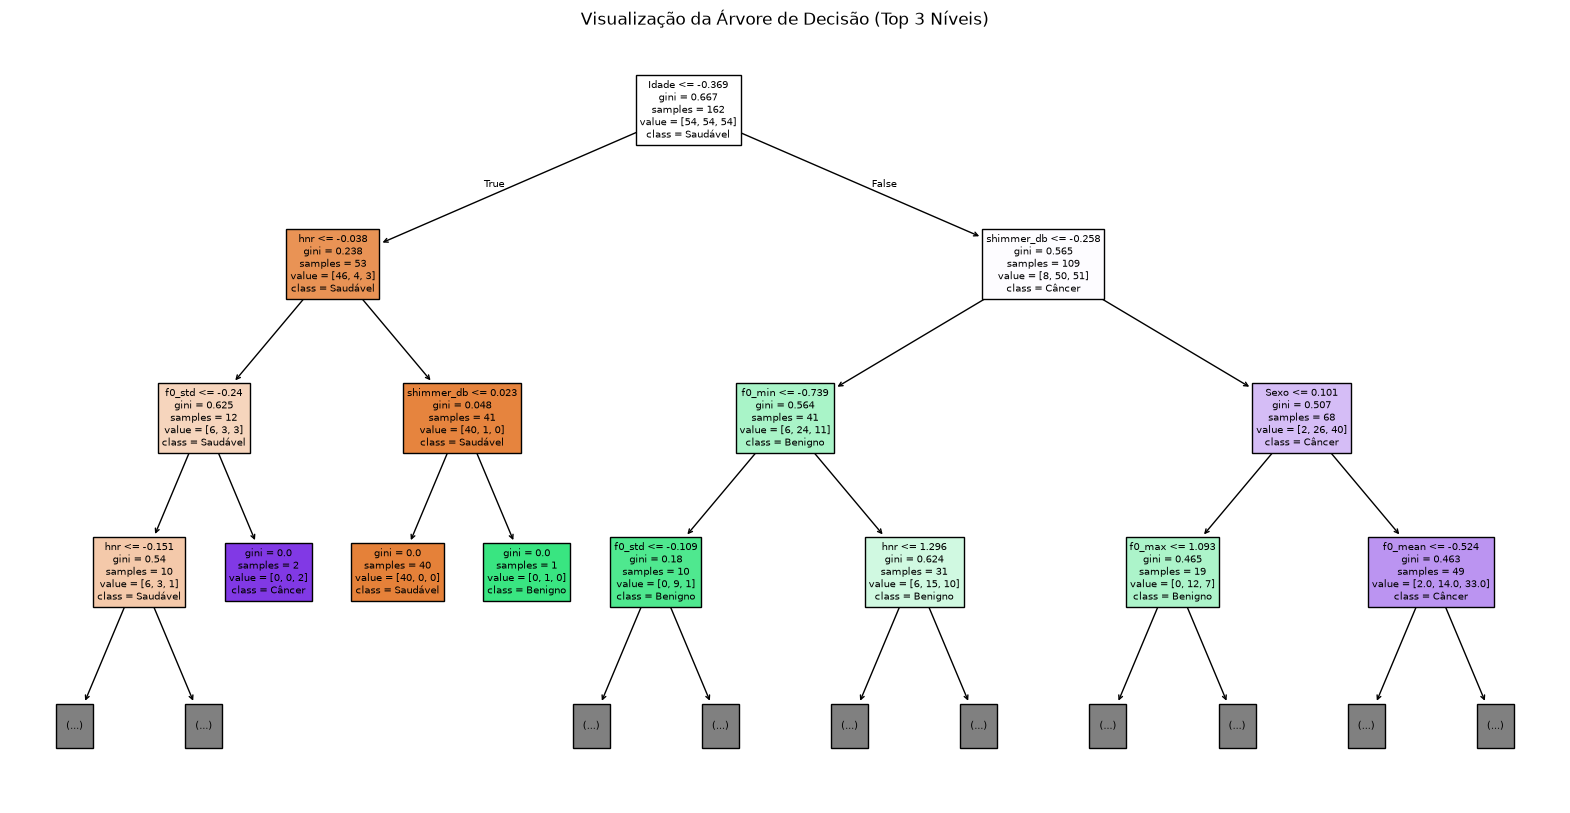

In [7]:
plt.figure(figsize=(20, 10))
plot_tree(modelo_tree, filled=True, feature_names=X_train.columns, class_names=['Saudável', 'Benigno', 'Câncer'], max_depth=3)
plt.title("Visualização da Árvore de Decisão (Top 3 Níveis)")
plt.show()

In [8]:
print("--- Relatório de Classificação ---")
print(classification_report(y_test, y_pred, target_names=['Saudável (0)', 'Benigno (1)', 'Câncer (2)']))

--- Relatório de Classificação ---
              precision    recall  f1-score   support

Saudável (0)       0.93      0.80      0.86       138
 Benigno (1)       0.75      0.54      0.63       142
  Câncer (2)       0.11      0.62      0.19        13

    accuracy                           0.67       293
   macro avg       0.60      0.65      0.56       293
weighted avg       0.81      0.67      0.72       293

